Ready with downloading 16 selected remote files to local cache: C:\Users\koenv\.cache\fairdatanow                                                                      


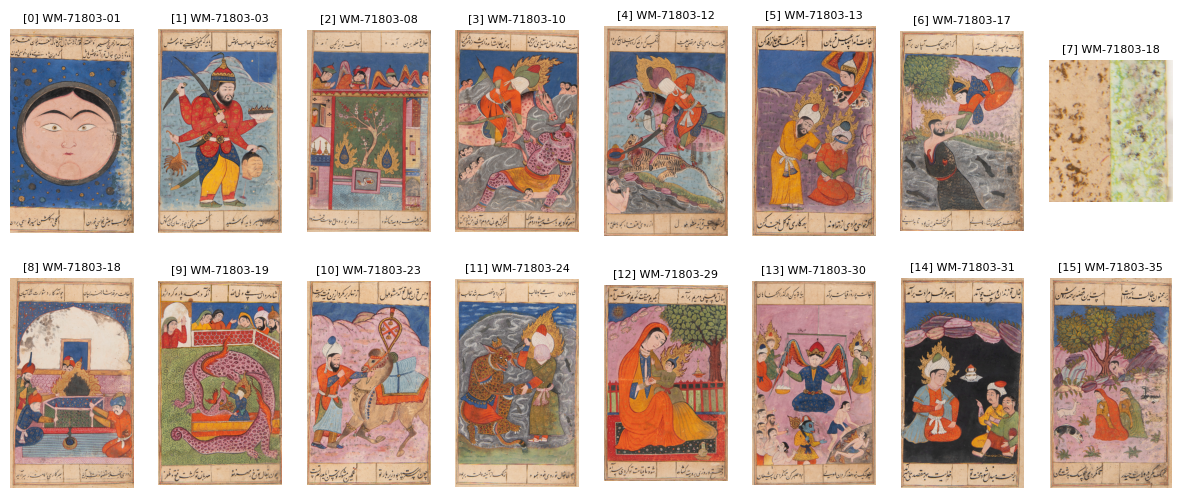

In [1]:
#|code-fold: true 
from fairdatanow import DataViewer
import matplotlib.pyplot as plt 
import os
import numpy as np 
import holoviews as hv
from holoviews import opts, streams
from holoviews.operation.datashader import rasterize
import json
import panel as pn
import maxrf4u as mx
import re

hv.extension('bokeh')

#|code-fold: true 
configuration = {
    'url': "https://laboppad.nl/falnama-project", 
    'user':    os.getenv('NC_AUTH_USER'),
    'password': os.getenv('NC_AUTH_PASS')
}

filters = {'extensions': ['.datastack']} 

dv = DataViewer(configuration, **filters)
datastack_files = dv.download_filtered() 

imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent)

object_nums = [re.sub(r'.*(WM-71803-\d\d).*', r'\1', dsf) for dsf in datastack_files]

fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[15, 6])
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(f'[{i}] {object_nums[i]}', fontsize=8)
    ax.axis('off')

In [2]:
n = 15
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

object_num = object_nums[n]

cube = ds.read('maxrf_cube', compute=False)
imvis_highres = ds.read('imvis_reg_highres')
imvis = ds.read('imvis_reg')
extent = ds.read('imvis_extent')
x_keVs = ds.read('maxrf_energies')

h, w, d = imvis.shape

# With Panel

In [20]:
points = hv.Points([], kdims=['x', 'y'])
point_stream = streams.PointDraw(source=points, num_objects=1, styles={'fill_color': ['cyan']})
rgb = rasterize(hv.RGB(imvis_highres, bounds=[-0.5,h-0.5,w-0.5,-0.5])).opts(aspect='equal', frame_width=500)
rgb = rgb.redim(x='rgb_x', y='rgb_y')

main = rgb * points
tabs = pn.Tabs(dynamic=True)

def update_tabs():
    tabs.clear()
    with open('file.json') as f:
        d = json.load(f)
        if d['fill_color']:
            for i, roi in enumerate(d['fill_color']):
                md = pn.pane.Markdown(f"x:{int(d['x'][i])}, y:{int(d['y'][i])}", name=roi)
                curve = pn.pane.HoloViews(hv.Curve(cube[int(d['y'][i]),int(d['x'][i])].compute()).opts(line_color=roi, frame_width=700))
                tabs.append(pn.Column(md, curve))
                            
def on_box_change(data):
    if data:
        with open("file.json", "w") as f:
            json.dump(data, f)
        update_tabs()
        
point_stream.add_subscriber(on_box_change)

In [21]:
pn.Row(main, tabs)

Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] Tabs(dynamic=True)

# DynamicMap

In [18]:
points = hv.Points([])
fake = {'x': [-1], 'y': [-1], 'fill_color': ['cyan']}
point_stream = streams.PointDraw(source=points, num_objects=3, data=fake, styles={'fill_color': ['cyan']})

def show_curve(data=None):
    if data:
        for i, color in enumerate(data['fill_color']):
            y = int(data['y'][i])
            x = int(data['x'][i])
            num_arr = cube[y,x].compute()
        return hv.Curve(num_arr).opts(color=color)
    
dmap = hv.DynamicMap(show_curve, streams=[point_stream])

In [19]:
rgb * points + dmap

:Layout
   .DynamicMap.I  :DynamicMap   []
      :Overlay
         .RGB.I    :RGB   [rgb_x,rgb_y]   (R,G,B)
         .Points.I :Points   [x,y]
   .DynamicMap.II :DynamicMap   []
      :Curve   [x]   (y)

# Without Panel

In [3]:
import moseley
ppa = moseley.PeakPatternAtlas()


Ready building Peak Pattern Atlas!                                   


In [16]:
points = hv.Points([]).opts(size=10)
point_stream = streams.PointDraw(source=points, num_objects=3, styles={'fill_color': ['cyan', 'lime', 'orange']})

pointer = streams.PointerXY(x=0, y=0)
pointer_dmap = hv.DynamicMap(lambda x, y: hv.VLine(x), streams=[pointer])

rgb = rasterize(hv.RGB(imvis_highres, bounds=[-0.5,h-0.5,w-0.5,-0.5])).opts(aspect='equal', frame_width=500)
rgb = rgb.redim(x='rgb_x', y='rgb_y')

main = rgb * points
tabs = pn.Tabs(dynamic=True)

Energy = hv.Dimension('Energy', unit='keV', range=(0, 20))
atlas = ppa.plot_atlas()

def update_tabs():
    tabs.clear()
    with open('file.json') as f:
        d = json.load(f)
        if d['fill_color']:
            li = []
            for i, roi in enumerate(d['fill_color']):
                curve = hv.Curve((x_keVs, cube[int(d['y'][i]),int(d['x'][i])].compute()), Energy).opts(line_color=roi, frame_width=500)
                li.append(curve)
            tabs.append(pn.Column(pn.pane.HoloViews(atlas * pointer_dmap),
                                pn.pane.HoloViews(hv.Overlay(li) * pointer_dmap)
                                 ))
                            
def on_box_change(data):
    if data:
        with open("file.json", "w") as f:
            json.dump(data, f)
        update_tabs()
        
point_stream.add_subscriber(on_box_change)

In [17]:
pn.Row(main, tabs)

Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] Tabs(dynamic=True)